#  Model-2 GoogLeNet


In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.models import googlenet, GoogLeNet_Weights
from torch.utils.data import DataLoader
from torchinfo import summary
import time

import sys
sys.path.append("..")
from utils.metrics import evaluate_model,compare_splits

SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
DATA_PATH = "../dataset/processed"
MODEL_PATH = "../models"

os.makedirs(MODEL_PATH, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4

# Loading Data

In [3]:
transform = transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)),transforms.ToTensor()])

train_data = datasets.ImageFolder(os.path.join(DATA_PATH, "train"),transform=transform)
val_data = datasets.ImageFolder(os.path.join(DATA_PATH, "val"),transform=transform)
test_data = datasets.ImageFolder(os.path.join(DATA_PATH, "test"),transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

NUM_CLASSES = len(train_data.classes)
print("Classes:", NUM_CLASSES)

Classes: 38


# Loading Model

In [4]:
weights = GoogLeNet_Weights.DEFAULT
model = googlenet(weights=weights,aux_logits=True)
model.aux_logits = False
model.aux1 = None
model.aux2 = None

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features,NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.fc.parameters(),lr=LR)

/home/rishi_677/Plant_Disease_DAC_Project/venv/lib/python3.12/site-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(


In [5]:
print(summary(model,input_size=(1, 3, IMG_SIZE, IMG_SIZE)))

Layer (type:depth-idx)                   Output Shape              Param #
GoogLeNet                                [1, 38]                   --
├─BasicConv2d: 1-1                       [1, 64, 112, 112]         --
│    └─Conv2d: 2-1                       [1, 64, 112, 112]         (9,408)
│    └─BatchNorm2d: 2-2                  [1, 64, 112, 112]         (128)
├─MaxPool2d: 1-2                         [1, 64, 56, 56]           --
├─BasicConv2d: 1-3                       [1, 64, 56, 56]           --
│    └─Conv2d: 2-3                       [1, 64, 56, 56]           (4,096)
│    └─BatchNorm2d: 2-4                  [1, 64, 56, 56]           (128)
├─BasicConv2d: 1-4                       [1, 192, 56, 56]          --
│    └─Conv2d: 2-5                       [1, 192, 56, 56]          (110,592)
│    └─BatchNorm2d: 2-6                  [1, 192, 56, 56]          (384)
├─MaxPool2d: 1-5                         [1, 192, 28, 28]          --
├─Inception: 1-6                         [1, 256, 28, 28]  

# Model Training

In [6]:
print("\n" + "="*60)
print("\t\t    TRAINING STARTED")
print("="*60 + "\n")
total_time=0

for epoch in range(EPOCHS):
    start = time.time()
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    val_metrics = evaluate_model(model,val_loader,device,show=False)
    val_acc = val_metrics["Accuracy"]
    t = time.time() - start
    total_time+=t
    
    print(
        f"[Epoch {epoch+1:02d}/{EPOCHS}] "
        f"Loss={avg_loss:.4f}  "
        f"ValAcc={val_acc:.4f}  "
        f"Time={t:.2f}s"
    )

print("\n Training Finished \n")
print(f"Total Time Taken : {total_time:.2f}s")
print(f"Average Time Taken per epoch : {(total_time/EPOCHS):.2f}s")


		    TRAINING STARTED

[Epoch 01/10] Loss=1.9767  ValAcc=0.8541  Time=99.57s
[Epoch 02/10] Loss=0.8572  ValAcc=0.8795  Time=96.22s
[Epoch 03/10] Loss=0.6009  ValAcc=0.8975  Time=92.55s
[Epoch 04/10] Loss=0.4910  ValAcc=0.9066  Time=97.91s
[Epoch 05/10] Loss=0.4276  ValAcc=0.9119  Time=93.64s
[Epoch 06/10] Loss=0.3845  ValAcc=0.9221  Time=93.48s
[Epoch 07/10] Loss=0.3573  ValAcc=0.9217  Time=97.07s
[Epoch 08/10] Loss=0.3342  ValAcc=0.9288  Time=93.16s
[Epoch 09/10] Loss=0.3185  ValAcc=0.9295  Time=96.41s
[Epoch 10/10] Loss=0.3036  ValAcc=0.9333  Time=94.17s

 Training Finished 

Total Time Taken : 954.19s
Average Time Taken per epoch : 95.42s


In [7]:
model_file = os.path.join(MODEL_PATH,"googlenet.pth")
torch.save(model.state_dict(),model_file)
print("Model Saved :", model_file)

Model Saved : ../models/googlenet.pth


# Model Evaluation

TRAINING DATA


===== METRICS =====


Metrics,Value
Accuracy,0.943346
Precision,0.943365
Recall,0.943079
F1_Score,0.942786
ROC_AUC,0.999083
Log_loss,0.222506



============================ CONFUSION MATRIX =============================


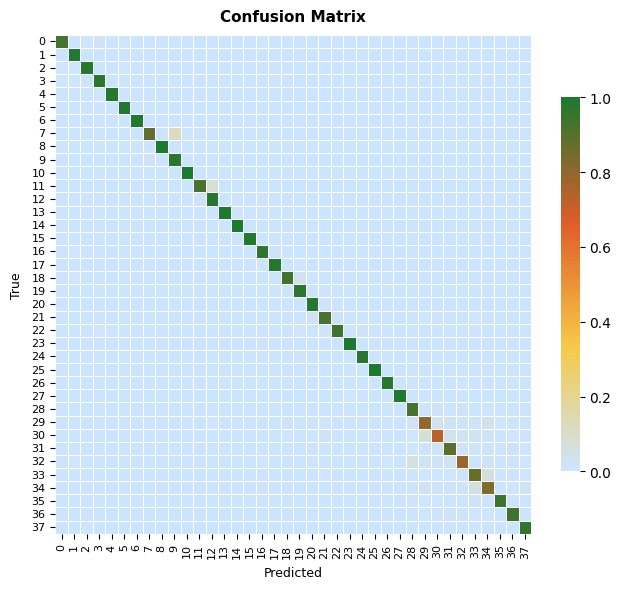


==================================== ROC CURVE ====================================


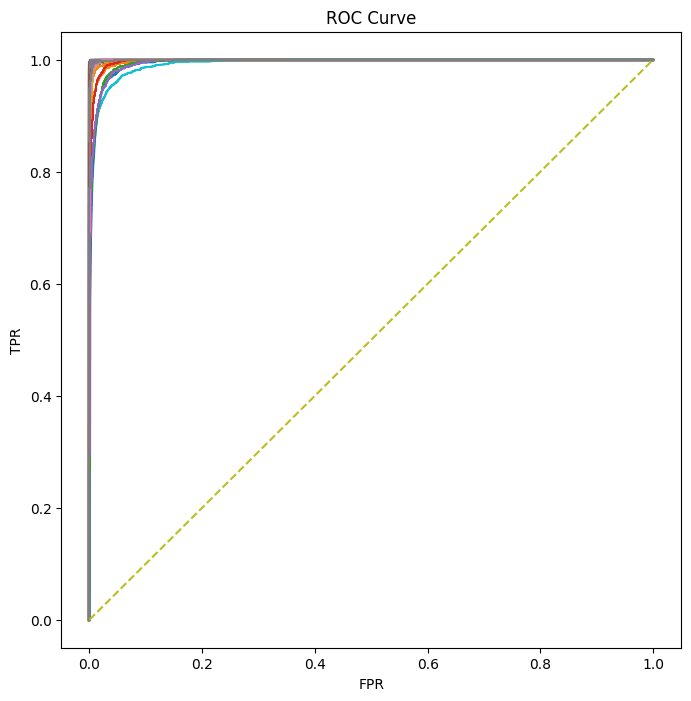

In [8]:
print("TRAINING DATA\n")
train_metrics = evaluate_model(model,train_loader,device,class_names=train_data.classes)

VALIDATION DATA


===== METRICS =====


Metrics,Value
Accuracy,0.933333
Precision,0.933501
Recall,0.933126
F1_Score,0.932597
ROC_AUC,0.998921
Log_loss,0.240335



============================ CONFUSION MATRIX =============================


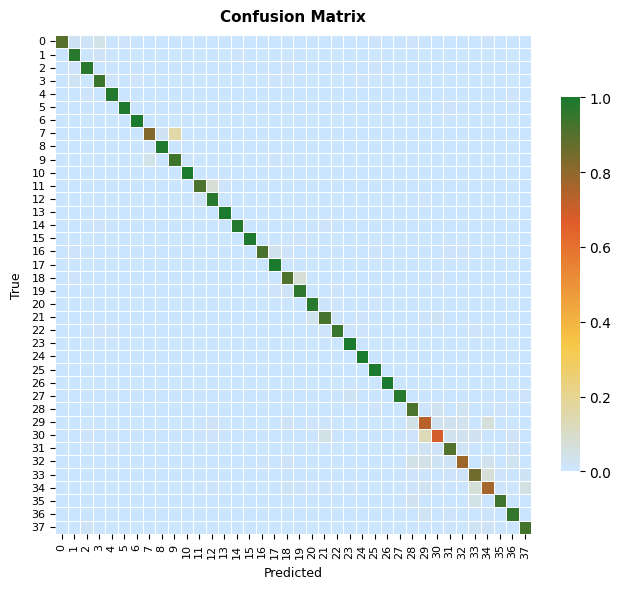


==================================== ROC CURVE ====================================


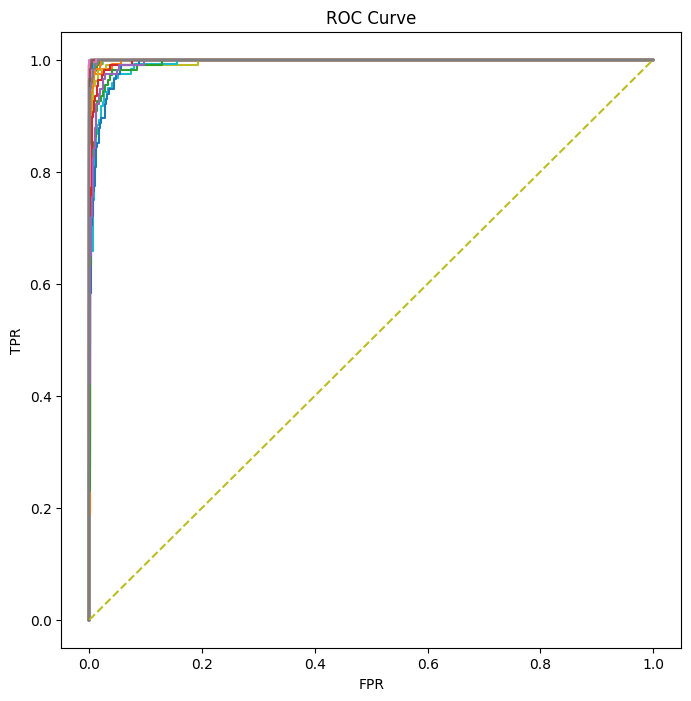

In [9]:
print("VALIDATION DATA\n")
val_metrics = evaluate_model(model,val_loader,device,class_names=train_data.classes)

TESTING DATA


===== METRICS =====


Metrics,Value
Accuracy,0.933564
Precision,0.933487
Recall,0.933393
F1_Score,0.932953
ROC_AUC,0.998937
Log_loss,0.240940



============================ CONFUSION MATRIX =============================


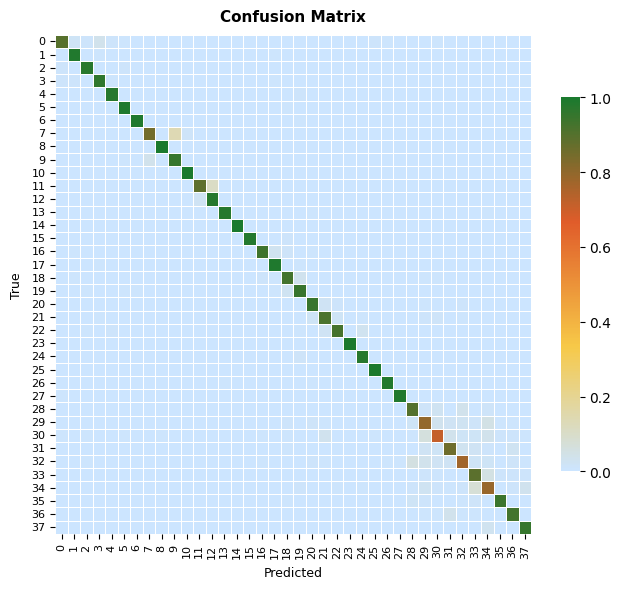


==================================== ROC CURVE ====================================


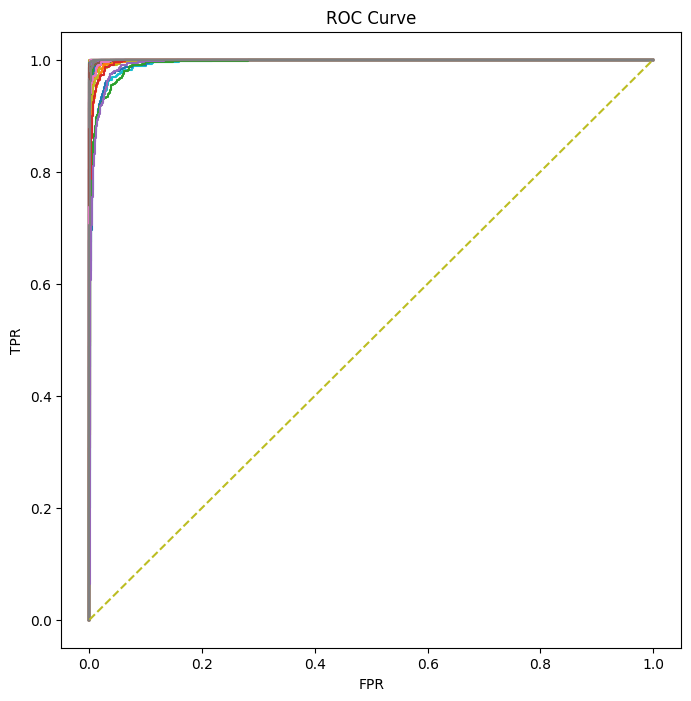

In [10]:
print("TESTING DATA\n")
test_metrics = evaluate_model(model,test_loader,device,class_names=train_data.classes)


================ SPLIT COMPARISON ================


,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Log_loss
train,0.9433,0.9434,0.9431,0.9428,0.9991,0.2225
val,0.9333,0.9335,0.9331,0.9326,0.9989,0.2403
test,0.9336,0.9335,0.9334,0.9330,0.9989,0.2409


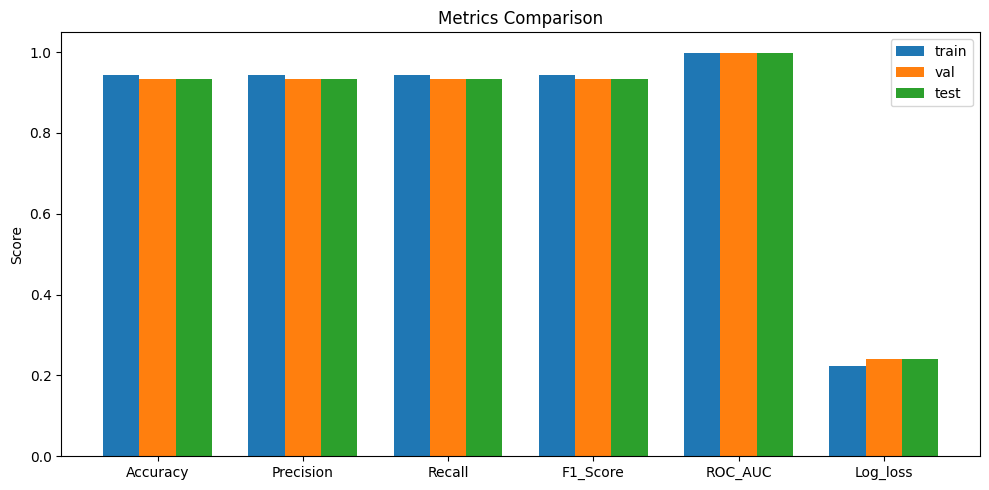

In [11]:
df_comparison=compare_splits(train_metrics,val_metrics,test_metrics)